# Notebook 7 – AC electricity consumption downscaling

This notebook downscales projected AC electricity consumption from a single city-level datapoint (NUTS region) to finer spatial units (CAPs and Municipi) for future years (2030, 2040, 2050). It combines gridded heat hazard, AC coverage, and population projections to produce scenario-specific maps and summary tables of AC use.

## Purpose

- Convert NUTS-level AC electricity use (kWh per AC user per year) into spatially explicit estimates.
- Produce CAP-level and Municipio-level indicators of:
  - AC consumption per AC user (kWh/user/yr)
  - AC consumption per capita (kWh/cap/yr)
  - Total AC electricity use (GWh/yr)
- Ensure consistency with:
  - City-wide AC penetration/ownership targets from Notebook 5
  - Population / exposure scenarios from the exposure manifest
  - City-level AC kWh/user values from the NUTS CSV.

## Inputs

- City configuration from `configs/<city>.yml` (AC settings, SSP scenario, NUTS ID, years).
- Ref grid and city mask (`template_ref.tif`, `city_mask.tif`) from previous notebooks.
- Gridded T2M hazard stack (`t2m_hazard_2030_2100_*.npz`) from Notebook 3.
- AC coverage maps by year (`ac_coverage_maps_<slug>.npz`) and city-level AC shares from Notebook 5.
- Population and age structure on the reference grid:
  - Baseline grids (`pop_on_ref`, `age_on_ref`) and
  - Scenario grids by year read from `exposure_manifest.json`.
- CAP and Municipio data:
  - CAP raster on ref grid (`cap_on_ref`) and CAP polygons/LUTs from Notebook 6.
  - Municipio raster (`muni_on_ref`) and Municipio polygons from the regions geopackage.
- NUTS-level AC electricity CSV (kWh per AC user per year) for the chosen SSP and NUTS ID.

## Method (core steps)

1. **City-level AC use:**  
   Read the NUTS CSV, select the configured NUTS ID and SSP scenario, and extract kWh per AC user for the target years. Save a small city-level time series.

2. **CAP-level per-user variation (hazard-based):**  
   - Compute a population-weighted heat hazard index per CAP using the T2M stack and population grids.  
   - Draw one random “effect” per CAP (fixed across years) from a normal distribution.  
   - For each year, create CAP-level kWh per AC user values as deviations around the city mean, with dispersion scaled by the ratio of local CAP hazard to the city-wide hazard.  
   - Rescale the CAP values so that the users-weighted city mean exactly matches the NUTS kWh per AC user for that year.

3. **Grid-level consumption and CAP aggregation:**  
   - Paint CAP-level per-user values back to the reference grid.  
   - Combine with AC coverage and population grids to obtain:
     - kWh per AC user (grid),
     - kWh per capita (grid),
     - total kWh (grid).  
   - Aggregate to CAPs to obtain:
     - AC share (users/pop),
     - kWh per AC user (CAP),
     - kWh per capita (CAP),
     - total kWh (CAP).

4. **Municipio aggregation:**  
   - Using the Municipio raster and polygons, aggregate pixel-level results to Municipi.  
   - Compute the same indicators (AC share, per-user, per-capita, total kWh) and verify that Municipi + “outside Municipi” sum back to the city totals.

## Outputs

- **CAP-level:**
  - `*_cap_ac_consumption_summary.csv` – per CAP and year: population, AC share, kWh per AC user, kWh per capita, total kWh (and GWh).
  - `*_cap_ac_consumption_map.geojson` – CAP geometries with the same indicators for mapping.

- **Municipio-level:**
  - `*_muni_ac_consumption_summary.csv` – per Municipio and year: population, AC share, kWh per AC user, kWh per capita, total kWh (and GWh).
  - `*_muni_ac_consumption_map.geojson` – Municipio geometries with the same indicators for mapping.

- **Diagnostics & plots:**
  - City-level checks ensuring:
    - AC shares from the maps match the NB5 targets.
    - Users-weighted mean kWh per AC user equals the NUTS input values.
  - Ranking tables and maps showing spatial patterns in:
    - kWh per AC user,
    - kWh per capita,
    - total kWh across CAPs and Municipi.

## Interpretation notes

- **Per AC user vs per capita:**  
  - *Per AC user* maps show average AC electricity use among households that own AC.  
  - *Per capita* maps divide the same total AC use by the entire population, so they are roughly:  
    _kWh per capita ≈ AC ownership share × kWh per AC user_.  
  - CAPs or Municipi with low ownership but intense usage per user can look modest per capita, while areas with high ownership levels appear high on per-capita maps.

- **CAPs vs Municipi:**  
  Municipio indicators are population-weighted aggregates of the underlying pixel/CAP values falling inside each Municipio. Differences between per-capita rankings and total-kWh rankings reflect the combined effect of intensity and population size.

In [11]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [13]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [14]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [15]:
# helper: picking first existing path from candidates 
def _first_existing(*cands, glob_pattern=None):
    for p in cands:
        p = Path(p)
        if p.exists():
            return p
    if glob_pattern is not None:
        hits = sorted(Path(OUT).glob(glob_pattern))
        if len(hits) == 1:
            return hits[0]
    return None

In [16]:
import numpy as np
import rasterio as rio
import geopandas as gpd
import pandas as pd
from pathlib import Path
import json 

# FUA / Regions paths
fua_gpkg = Path(paths.get("fua_gpkg", OUT / f"{SLUG}_fua.gpkg"))
fua_gpkg = _first_existing(fua_gpkg, OUT / "fua.gpkg", glob_pattern="*_fua.gpkg")
assert fua_gpkg and fua_gpkg.exists(), "Missing FUA geopackage."

regions_gpkg = Path(paths.get("regions_gpkg", OUT / f"{SLUG}_regions.gpkg"))
regions_gpkg = _first_existing(regions_gpkg, OUT / "regions.gpkg", glob_pattern="*_regions.gpkg")
assert regions_gpkg and regions_gpkg.exists(), "Missing regions geopackage."

muni_on_ref_tif = Path(paths.get("muni_on_ref_tif", OUT / f"{SLUG}_muni_on_ref.tif"))
muni_on_ref_tif = _first_existing(muni_on_ref_tif, OUT / "muni_on_ref.tif", glob_pattern="*_muni_on_ref.tif")
assert muni_on_ref_tif and muni_on_ref_tif.exists(), "Missing muni_on_ref.tif (save it in NB5)."

# LUTs
muni_lut_csv = Path(paths.get("muni_lut_csv", OUT / f"{SLUG}_muni_lut.csv"))
muni_lut_csv = _first_existing(muni_lut_csv, OUT / "muni_lut.csv", glob_pattern="*_muni_lut.csv")
assert muni_lut_csv and muni_lut_csv.exists(), "Missing muni_lut.csv (save it in NB5)."

lut = (
    pd.read_csv(muni_lut_csv)
    .assign(muni_id=lambda d: d["muni_id"].astype(int))
    .sort_values("muni_id")
)
print("Using muni LUT:", muni_lut_csv.name, "| rows:", len(lut))

cap_gpkg = Path(paths.get("cap_gpkg", OUT / f"{SLUG}_cap.gpkg"))
cap_gpkg = _first_existing(cap_gpkg, OUT / "cap.gpkg", glob_pattern="*_cap.gpkg")
assert cap_gpkg and cap_gpkg.exists(), "Missing CAP geopackage."

cap_lut_csv = Path(paths.get("cap_lut_csv", OUT / f"{SLUG}_cap_lut.csv"))
cap_lut_csv = _first_existing(cap_lut_csv, OUT / "cap_lut.csv", glob_pattern="*_cap_lut.csv")
assert cap_lut_csv and cap_lut_csv.exists(), "Missing cap_lut.csv (save it in NB6)."

cap_ref_lut = (pd.read_csv(cap_lut_csv).astype({"cap_id": int, "cap5": str}).drop_duplicates())
print("Using CAP LUT:", cap_lut_csv.name, "| rows:", len(cap_ref_lut))

cap_wgs84_lut_path = Path(paths.get("cap_wgs84_lut", OUT / f"{SLUG}_cap_wgs84_lut.csv"))
cap_wgs84_lut_path = _first_existing(cap_wgs84_lut_path, OUT / "cap_wgs84_lut.csv", glob_pattern="*_cap_wgs84_lut.csv")
cap_wgs84_lut_df = None
if cap_wgs84_lut_path and cap_wgs84_lut_path.exists():
    cap_wgs84_lut_df = (pd.read_csv(cap_wgs84_lut_path).astype({"cap_id": int, "cap5": str}).drop_duplicates())
    print("Using CAP WGS84 LUT:", cap_wgs84_lut_path.name)

# Reference grid + city mask
tmpl_path = INT / "template_ref.tif" # T2M ref grid
mask_tif = INT / "city_mask.tif" # boolean mask on that grid
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
HGT, WDT = ref_meta["height"], ref_meta["width"]
with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# Hot-days stack
# T2M hazard stack on ref grid (mean daily T2M per year)
t2m_npz_path = _first_existing(
    INT / f"t2m_hazard_2030_2100_{SLUG}.npz",
    INT / "t2m_hazard_2030_2100.npz",
    glob_pattern="t2m_hazard_2030_2100*.npz"
)
assert t2m_npz_path and t2m_npz_path.exists(), "Missing T2M hazard .npz (run NB3)."

npz = np.load(t2m_npz_path)
YEARS = npz["years"].astype(int) # (n_years,)
DATA = npz["data"].astype("float32") # (n_years, HGT, WDT)
assert DATA.shape[1:] == (HGT, WDT), f"T2M hazard grid {DATA.shape[1:]} != ref grid {(HGT, WDT)}"
H2050 = DATA[list(YEARS).index(2050)]
print("Loaded T2M hazard:", t2m_npz_path.name, "| years:", YEARS.min(), "→", YEARS.max())

# AC coverage
# loading AC targets (city mean shares) produced by NB5 
targets_path = INT / f"ac_city_targets_{SLUG}.csv"
t = pd.read_csv(targets_path)
ac_city_by_year = dict(zip(t["year"].astype(int), t["ac_share"].astype(float)))

# loading AC coverage maps (CAP-based maps) produced by NB5 
cov_path = INT / f"ac_coverage_maps_{SLUG}.npz"
z = np.load(cov_path)
YEARS_COV = z["YEARS_AC"].astype(int).tolist()
year_to_k = {y: i for i, y in enumerate(YEARS_COV)}

coverage_base_3d = z["coverage_base_3d"].astype("float32")
coverage_policy_3d = z["coverage_policy_3d"].astype("float32")

def cov_base_for_year(y: int) -> np.ndarray:
    return coverage_base_3d[year_to_k[int(y)]]

def cov_policy_for_year(y: int) -> np.ndarray:
    return coverage_policy_3d[year_to_k[int(y)]]

# Population / CAP rasters
def _load_pop_on_ref(INT, SLUG, HGT, WDT):
    pop_npz_path = _first_existing(
        INT / f"pop_on_ref_{SLUG}.npz",
        INT / "pop_on_ref.npz",
        glob_pattern="pop_on_ref*.npz"
    )
    if pop_npz_path and pop_npz_path.exists():
        pop = np.load(pop_npz_path)["pop"].astype("float32")
    else:
        # fallback to GeoTIFF saved in NB5
        with rio.open(INT / "pop_on_ref.tif") as src:
            pop = src.read(1).astype("float32")
            assert (src.height, src.width) == (HGT, WDT), "pop_on_ref.tif grid mismatch."
    assert pop.shape == (HGT, WDT), f"pop_on_ref shape {pop.shape} != {(HGT, WDT)}"
    return pop

def _load_age_on_ref(INT, SLUG, HGT, WDT):
    age_npz_path = _first_existing(
        INT / f"age_on_ref_{SLUG}.npz",
        INT / "age_on_ref.npz",
        glob_pattern="age_on_ref*.npz"
    )
    if age_npz_path and age_npz_path.exists():
        d = np.load(age_npz_path)
        age = {"<15": d["lt15"].astype("float32"), "15-64": d["a15_64"].astype("float32"), "65+": d["g65"].astype("float32")}
    else:
        # fallback to per-band GeoTIFFs saved in NB5
        age = {}
        with rio.open(INT / "age_lt15_on_ref.tif") as s:
            age["<15"] = s.read(1).astype("float32")
        with rio.open(INT / "age_15_64_on_ref.tif") as s:
            age["15-64"] = s.read(1).astype("float32")
        with rio.open(INT / "age_65p_on_ref.tif") as s:
            age["65+"] = s.read(1).astype("float32")
    for k,v in age.items():
        assert v.shape == (HGT, WDT), f"age {k} shape {v.shape} != {(HGT, WDT)}"
    return age

# using them
pop_on_ref = _load_pop_on_ref(INT, SLUG, HGT, WDT)
age_on_ref = _load_age_on_ref(INT, SLUG, HGT, WDT)

print(
    "Loaded exposure:",
    f"\n pop_on_ref: {pop_on_ref.shape}, sum={np.nansum(pop_on_ref):.0f}",
    f"\n age lt15: {age_on_ref['<15'].shape}, sum={np.nansum(age_on_ref['<15']):.0f}",
    f"\n age 15-64: {age_on_ref['15-64'].shape}, sum={np.nansum(age_on_ref['15-64']):.0f}",
    f"\n age 65+: {age_on_ref['65+'].shape}, sum={np.nansum(age_on_ref['65+']):.0f}",
)

# multi-year exposure (population / age) from exposure_manifest.json 
expo_manifest_path = INT / "exposure_manifest.json"

age_on_ref_by_year = {}
pop_on_ref_by_year = {}

if expo_manifest_path.exists():
    with open(expo_manifest_path) as f:
        expo_manifest = json.load(f)

    scen_dict = expo_manifest.get("scenarios", {})

    # priority: explicit scenario.code in cfg (if present)
    scenario_cfg = (cfg or {}).get("scenario", {}) or {}
    SCEN_CODE = scenario_cfg.get("code")

    # exp_scenario from YAML 
    if not SCEN_CODE:
        SCEN_CODE = cfg.get("exp_scenario")

    # derive from AC SSP (as in NB5/6)
    if (not SCEN_CODE) or (SCEN_CODE not in scen_dict):
        ac_cfg = cfg.get("ac", {})
        ssp = ac_cfg.get("ssp", None)
        if ssp is not None:
            for cand in (f"SSP{ssp}", f"ssp{ssp}", f"ssp{ssp}".lower(), f"SSP{ssp}".upper()):
                if cand in scen_dict:
                    SCEN_CODE = cand
                    break

    # final fallback: first available scenario
    if (not SCEN_CODE) or (SCEN_CODE not in scen_dict):
        SCEN_CODE = sorted(scen_dict.keys())[0]

    print(f"Using exposure scenario for AC population: {SCEN_CODE}")
    scen_rec = scen_dict[SCEN_CODE]

    for year_str, rec in scen_rec.items():
        y = int(year_str)

        ages_npz = np.load(rec["age_npz"])
        pop_npz  = np.load(rec["pop_npz"])

        age_on_ref_by_year[y] = {
            "<15":   ages_npz["lt15"].astype("float32"),
            "15-64": ages_npz["a15_64"].astype("float32"),
            "65+":   ages_npz["g65"].astype("float32"),
        }
        pop_on_ref_by_year[y] = pop_npz["pop"].astype("float32")

        # shape consistency
        assert pop_on_ref_by_year[y].shape == CITY_MASK.shape, f"pop grid {y} shape mismatch"
        for grp in ["<15", "15-64", "65+"]:
            assert age_on_ref_by_year[y][grp].shape == CITY_MASK.shape, f"age {grp} grid {y} shape mismatch"

    # baseline (for descriptive parts that still use pop_on_ref / age_on_ref)
    BASE_EXPO_YEAR = min(pop_on_ref_by_year.keys())
    age_on_ref_base = age_on_ref_by_year[BASE_EXPO_YEAR]
    pop_on_ref_base = pop_on_ref_by_year[BASE_EXPO_YEAR]

    # overwrite single-year variables to refer to the baseline year,
    # so all code that still uses age_on_ref / pop_on_ref stays consistent
    age_on_ref = age_on_ref_base
    pop_on_ref = pop_on_ref_base

    def pop_for_year(year: int) -> np.ndarray:
        year = int(year)
        if year not in pop_on_ref_by_year:
            raise KeyError(f"No population grid for year {year} in exposure scenario {SCEN_CODE}.")
        return pop_on_ref_by_year[year]

else:
    print("WARNING: exposure_manifest.json not found – AC notebook will reuse baseline pop_on_ref for all years.")

    def pop_for_year(year: int) -> np.ndarray:
        # fallback: always return baseline
        return pop_on_ref

# CAP raster on ref grid
def _load_cap_on_ref(INT, SLUG, HGT, WDT):
    cap_npz_path = _first_existing(
        INT / f"cap_on_ref_{SLUG}.npz",
        INT / "cap_on_ref.npz",
        glob_pattern="cap_on_ref*.npz"
    )
    if cap_npz_path and cap_npz_path.exists():
        cap = np.load(cap_npz_path)["cap_on_ref"].astype("int32")
    else:
        # fallback to GeoTIFF written in NB6
        with rio.open(INT / f"cap_on_ref_{SLUG}.tif") as src:
            cap = src.read(1).astype("int32")
            assert (src.height, src.width) == (HGT, WDT), "cap_on_ref.tif grid mismatch."
    assert cap.shape == (HGT, WDT), f"cap_on_ref shape {cap.shape} != {(HGT, WDT)}"
    return cap

cap_on_ref = _load_cap_on_ref(INT, SLUG, HGT, WDT)

# Optional: CAP_MASK from coverage NPZ if present, else derive from CAP raster
if "CAP_MASK" in z.files:
    CAP_MASK = z["CAP_MASK"].astype(bool)
else:
    CAP_MASK = (CITY_MASK & (cap_on_ref > 0))

# Vectors
fua = gpd.read_file(fua_gpkg).to_crs("EPSG:4326")
regions = gpd.read_file(regions_gpkg, layer="regions").set_crs("EPSG:4326")
muni = gpd.read_file(regions_gpkg, layer="muni").set_crs("EPSG:4326")

with rio.open(muni_on_ref_tif) as src:
    muni_on_ref = src.read(1).astype("int32")
    assert (src.crs == ref_meta["crs"]) and (src.transform == ref_meta["transform"]), "Grid mismatch."

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)
print("Unique muni IDs on grid (>=0):", int(np.unique(muni_on_ref[muni_on_ref >= 0]).size))

cap_ref = gpd.read_file(cap_gpkg, layer="cap").to_crs(ref_meta["crs"])
cap_4326 = gpd.read_file(cap_gpkg, layer="cap_wgs84").to_crs("EPSG:4326")

print(
    "Loaded:",
    "\n FUA:", fua_gpkg.name,
    "\n Regions:", regions_gpkg.name,
    "\n muni_on_ref:", muni_on_ref_tif.name, muni_on_ref.shape,
    "\n CAPs:", cap_gpkg.name
)

Using muni LUT: rome_muni_lut.csv | rows: 16
Using CAP LUT: rome_cap_lut.csv | rows: 118
Using CAP WGS84 LUT: rome_cap_wgs84_lut.csv
Loaded T2M hazard: t2m_hazard_2030_2100_rome.npz | years: 2030 → 2050
Loaded exposure: 
 pop_on_ref: (301, 301), sum=2548154 
 age lt15: (301, 301), sum=277144 
 age 15-64: (301, 301), sum=1580341 
 age 65+: (301, 301), sum=690669
Using exposure scenario for AC population: SSP2
Loaded regions: 16 polygons; muni_on_ref shape: (301, 301)
Unique muni IDs on grid (>=0): 16
Loaded: 
 FUA: rome_fua.gpkg 
 Regions: rome_regions.gpkg 
 muni_on_ref: rome_muni_on_ref.tif (301, 301) 
 CAPs: rome_cap.gpkg


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Parametrisation of the AC costs: using the gridded AC data : divide TWh layers by pop layers, convert units to get average AC electricity use (kWh / capita + year)
</blockquote>

**Loading the data**

In [17]:
# AC kWh per AC-user (city) from NUTS CSV (no NetCDF / no pixel)
import pandas as pd
import numpy as np
import re

ac_cfg = cfg.get("ac", {})
kwh_path = P(ac_cfg.get("kwh_file", ""))
assert kwh_path.exists(), f"Missing AC kWh CSV: {kwh_path}"

# numeric scenario from YAML
ssp_choice = int(ac_cfg.get("ssp", 2))          # 1,2,3,5
print(f"[AC kWh] Using scenario ssp = {ssp_choice} (from cfg['ac']['ssp'])")
years_interest = list(ac_cfg.get("years", [2030, 2040, 2050]))
nuts_id = ac_cfg.get("nuts_id", None)
assert nuts_id, "cfg['ac']['nuts_id'] missing (e.g. 'ITI43')."

cols = ac_cfg.get("kwh_columns", {}) or {}
COL_ID = cols.get("id", "NUTS_ID")
COL_SSP = cols.get("scenario", "Scenario")
COL_YEAR = cols.get("year", "year")
COL_VAL = cols.get("value", "value")

df = pd.read_csv(kwh_path)

need = [COL_ID, COL_SSP, COL_YEAR, COL_VAL]
missing = [c for c in need if c not in df.columns]
assert not missing, f"Missing columns in {kwh_path.name}: {missing}. Found: {list(df.columns)}"

def _scenario_to_int(x):
    s = str(x)
    m = re.search(r"(\d+)", s)   # so it handles "2" and "SSP2"
    return int(m.group(1)) if m else None

df = df.copy()
df["_scenario_int"] = df[COL_SSP].map(_scenario_to_int)
df[COL_YEAR] = pd.to_numeric(df[COL_YEAR], errors="coerce")
df[COL_VAL] = pd.to_numeric(df[COL_VAL], errors="coerce").replace([-999, -9999], np.nan)

sub = df[
    (df[COL_ID].astype(str) == str(nuts_id)) &
    (df["_scenario_int"] == ssp_choice)
].dropna(subset=[COL_YEAR, COL_VAL])

assert len(sub) > 0, (
    f"No rows found for NUTS_ID={nuts_id} and Scenario={ssp_choice} in {kwh_path.name}. "
    f"Check values in columns {COL_ID} / {COL_SSP}."
)

series = (sub.groupby(sub[COL_YEAR].astype(int))[COL_VAL].mean()).to_dict()

missing_years = [y for y in years_interest if int(y) not in series]
assert not missing_years, f"Missing years in AC kWh CSV for {nuts_id}, Scenario={ssp_choice}: {missing_years}"

per_user_city_by_year = {int(y): float(series[int(y)]) for y in years_interest}
per_user_city = float(per_user_city_by_year[max(years_interest)])

print("AC per-AC-user from NUTS CSV (kWh/user/yr):")
for y in years_interest:
    print(f" {y}: {per_user_city_by_year[int(y)]:.3f}")

ac_city_series = pd.DataFrame({
    "year": years_interest,
    "kwh_per_ac_user_city": [per_user_city_by_year[int(y)] for y in years_interest],
})

out_csv = INT / f"ac_per_user_city_{SLUG}.csv"
ac_city_series.to_csv(out_csv, index=False)
print("Saved:", out_csv)

[AC kWh] Using scenario ssp = 2 (from cfg['ac']['ssp'])
AC per-AC-user from NUTS CSV (kWh/user/yr):
 2030: 1574.514
 2040: 1662.144
 2050: 1739.301
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_per_user_city_rome.csv


**Downscaling the AC electricity consumption at the CAP level**: based not on the income but on the hazard level

**Question of the shape**: message of Giacomo: following the approach we used to create a variation across CAPs from a single datapoint for AC, also create a variation in consumption. The data point is already in per AC-user, so we just need to create a spread that follows a normal distribution with mean = the pixel value and proportional to the local heat levels

In [18]:
import numpy as np
import pandas as pd

# we now rely on per-year dict from the NetCDF step
assert ("per_user_city_by_year" in globals() and isinstance(per_user_city_by_year, dict) and len(per_user_city_by_year) > 0), \
 "per_user_city_by_year must be defined by the NetCDF/FUA selection cell."

years_interest = [2030, 2040, 2050]
cap_ids = cap_on_ref  # pop_grid will now be year-specific via pop_for_year

def _get_H_for_year(year):
    if year not in YEARS:
        raise KeyError(f"Year {year} not found in T2M YEARS: {list(YEARS)}")
    idx = list(YEARS).index(int(year))
    return DATA[idx, :, :]

def _cov_for_year(year):
    """ Return AC coverage map for a given year from the NB5 3D maps.
    NB5 already did the year-specific calibration, so no extra rescaling here.
    """
    year = int(year)
    if year not in year_to_k:
        raise KeyError(f"Year {year} not in YEARS_COV (from NB5): {YEARS_COV}")
    base = cov_base_for_year(year).astype("float32")
    return np.clip(base, 0.0, 1.0).astype("float32")

rng = np.random.default_rng(42)
sigma0 = 0.20 # base dispersion (20% of mean)
gamma = 1.0 # how strongly dispersion scales with hazard ratio

**CAP Maps or tables:**

In [19]:
# drawing ONE eps per CAP ONCE, and reuse it for all years 
# Use 2030 only to define the CAP set (ids) consistently.
H0 = _get_H_for_year(2030)
pop_grid0 = pop_for_year(2030)  # NEW: 2030 population
CAP_PIX0 = CITY_MASK & np.isfinite(H0) & (cap_ids > 0)
valid0 = CAP_PIX0 & np.isfinite(pop_grid0)

dfH0 = pd.DataFrame({
    "cap_id": cap_ids[valid0].ravel().astype(int),
    "pop": pop_grid0[valid0].ravel().astype(float),
    "H": H0[valid0].ravel().astype(float),
})

def _wavg_pop(g):
    w = g["pop"].to_numpy()
    x = g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_ids_all = (dfH0["cap_id"].drop_duplicates().sort_values().to_numpy())
eps_by_cap = dict(zip(cap_ids_all, rng.normal(0.0, 1.0, size=len(cap_ids_all))))


=== Year 2030 ===
AC share from map (city pop-weighted): 0.706
AC share from NB5 (target): 0.706
Per-user mean (city): 1574.5137939453125
AC share from map:  0.705737829208374
City total GWh:  2831.492864

=== Year 2040 ===
AC share from map (city pop-weighted): 0.740
AC share from NB5 (target): 0.740
Per-user mean (city): 1662.143798828125
AC share from map:  0.7400227189064026
City total GWh:  3060.843776

=== Year 2050 ===
AC share from map (city pop-weighted): 0.740
AC share from NB5 (target): 0.740
Per-user mean (city): 1739.3009033203125
AC share from map:  0.7400150299072266
City total GWh:  3140.329728


,year,ac_share_city,ac_share_from_map,per_user_city_input,per_user_city_realized,city_total_GWh
0,2030,0.705738,0.705738,1574.513550,1574.513794,2831.492864
1,2040,0.740043,0.740023,1662.143921,1662.143799,3060.843776
2,2050,0.740043,0.740015,1739.300659,1739.300903,3140.329728



==== CAP-level results for year 2030 ====
City pop: 2,548,154
City AC users: 1,798,329 (AC share ≈ 0.706)
City total AC electricity: 2831.493 GWh/yr
City per-AC-user mean (users-weighted): 1574.513512 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.822816,2225.171631,44494.561003,8.146537e+07,1830.906249,2030
1,78,0.980000,1805.050049,21992.931100,3.890438e+07,1768.949099,2030
2,107,0.980000,1759.312622,9290.892414,1.601867e+07,1724.126337,2030
3,110,0.980000,1733.219849,28695.673340,4.874119e+07,1698.555539,2030
4,71,0.953392,1745.684692,32908.612974,5.477055e+07,1664.322513,2030
5,105,0.980000,1687.601562,24897.302006,4.117639e+07,1653.849609,2030
6,112,0.980000,1676.418579,23655.270266,3.886301e+07,1642.890258,2030
7,66,0.915301,1732.857300,15601.997405,2.474610e+07,1586.085210,2030
8,61,0.933512,1676.489380,36202.427383,5.665764e+07,1565.023319,2030
9,109,0.980000,1586.601196,15981.706778,2.484946e+07,1554.869264,2030


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.498566,1029.383911,27875.780853,1.430630e+07,513.215943,2030
1,53,0.394069,1326.023926,103728.386872,5.420270e+07,522.544556,2030
2,103,0.438580,1208.898560,11587.980509,6.143925e+06,530.198121,2030
3,87,0.426566,1339.162109,20995.874457,1.199370e+07,571.240660,2030
4,88,0.411513,1451.931885,35544.090556,2.123719e+07,597.488646,2030
5,86,0.433096,1387.070923,34966.397318,2.100555e+07,600.735230,2030
6,52,0.406537,1482.915894,8590.451377,5.178837e+06,602.859679,2030
7,93,0.460502,1434.402832,27316.795412,1.804400e+07,660.545897,2030
8,41,0.380919,1789.083984,17621.180629,1.200877e+07,681.496460,2030
9,48,0.419827,1645.979248,37363.317451,2.581905e+07,691.026794,2030



Top 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.839950,1669.583862,80341.231564,1.126679e+08,1402.366577,2030
1,83,0.479281,1730.002808,124767.276052,1.034518e+08,829.158203,2030
2,55,0.883730,1489.942139,77077.603122,1.014886e+08,1316.706300,2030
3,63,0.976008,1406.480225,72016.976310,9.886030e+07,1372.736086,2030
4,62,0.822816,2225.171631,44494.561003,8.146537e+07,1830.906249,2030
5,59,0.674200,1643.372437,66337.303344,7.349915e+07,1107.961059,2030
6,50,0.778167,1810.427734,49859.790085,7.024321e+07,1408.814820,2030
7,89,0.614292,2011.537354,56324.068393,6.959801e+07,1235.670897,2030
8,82,0.923144,1628.178345,45832.143102,6.888769e+07,1503.043092,2030
9,73,0.569528,1703.497803,70384.133434,6.828597e+07,970.189759,2030


Bottom 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.757105,1787.415894,220.220836,2.980163e+05,1353.261212,2030
1,21,0.725357,1133.234375,1151.152290,9.462463e+05,821.999269,2030
2,24,0.754555,1446.741699,2401.749025,2.621859e+06,1091.645509,2030
3,44,0.588397,1556.014893,3973.220555,3.637701e+06,915.554811,2030
4,19,0.743386,944.525024,5608.371938,3.937902e+06,702.147095,2030
5,52,0.406537,1482.915894,8590.451377,5.178837e+06,602.859679,2030
6,103,0.438580,1208.898560,11587.980509,6.143925e+06,530.198121,2030
7,3,0.726864,1247.061035,9452.473548,8.568130e+06,906.443176,2030
8,33,0.755984,1532.037109,7703.112600,8.921712e+06,1158.195678,2030
9,87,0.426566,1339.162109,20995.874457,1.199370e+07,571.240660,2030


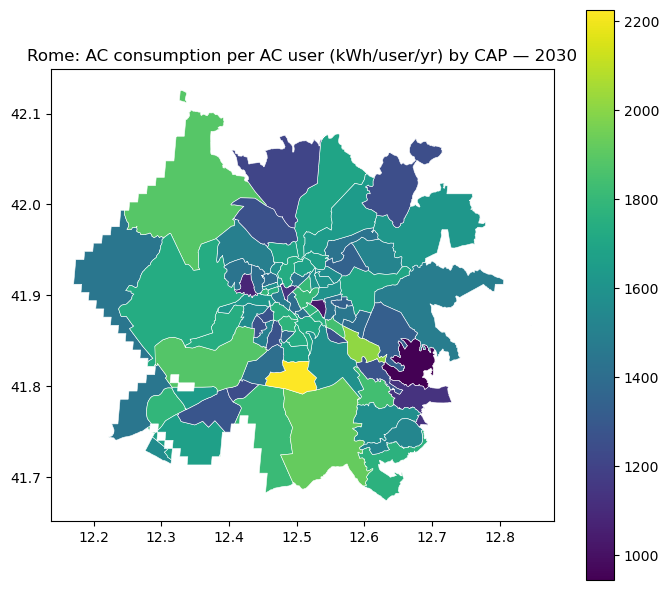

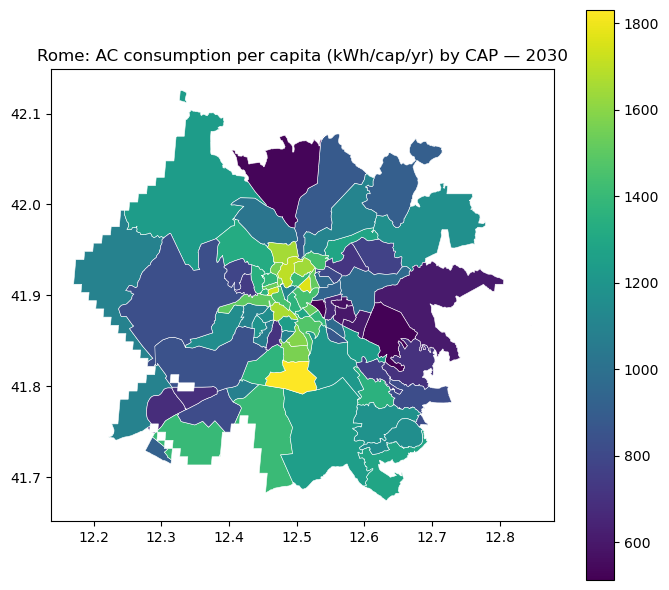


==== CAP-level results for year 2040 ====
City pop: 2,488,442
City AC users: 1,841,504 (AC share ≈ 0.740)
City total AC electricity: 3060.844 GWh/yr
City per-AC-user mean (users-weighted): 1662.143882 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.874065,2347.607910,43473.624215,8.920626e+07,2051.962893,2040
1,78,0.980000,1904.724487,21488.298754,4.011070e+07,1866.630000,2040
2,107,0.980000,1856.324097,9077.711077,1.651415e+07,1819.197622,2040
3,71,0.980000,1841.961060,32153.518115,5.804102e+07,1805.121824,2040
4,110,0.980000,1828.876587,28037.245293,5.025113e+07,1792.299073,2040
5,66,0.972683,1828.456421,15244.006432,2.711161e+07,1778.509283,2040
6,105,0.980000,1780.826416,24326.028329,4.245403e+07,1745.209963,2040
7,112,0.980000,1769.009155,23112.495390,4.006849e+07,1733.629028,2040
8,61,0.980000,1768.968262,35371.755198,6.132009e+07,1733.588991,2040
9,97,0.906411,1880.470581,16356.686710,2.787962e+07,1704.478519,2040


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.528313,1086.110840,27236.165337,1.562829e+07,573.806520,2040
1,53,0.416886,1399.283813,101348.429916,5.912076e+07,583.341614,2040
2,103,0.464348,1275.372559,11322.091913,6.705137e+06,592.217163,2040
3,87,0.451538,1413.145264,20514.119779,1.308983e+07,638.088684,2040
4,88,0.435487,1532.124512,34728.524087,2.317156e+07,667.219972,2040
5,86,0.458501,1463.752930,34164.085920,2.292864e+07,671.132874,2040
6,52,0.430181,1564.772705,8393.341704,5.649851e+06,673.134888,2040
7,93,0.487725,1513.616089,26690.005874,1.970332e+07,738.228518,2040
8,41,0.402864,1888.145874,17216.857598,1.309629e+07,760.666626,2040
9,48,0.444352,1736.939697,36506.008350,2.817583e+07,771.813476,2040



Top 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.892336,1761.942139,78497.785641,1.234177e+08,1572.244019,2040
1,83,0.507749,1825.553711,121904.435922,1.129961e+08,926.923890,2040
2,55,0.939019,1572.218872,75309.041560,1.111820e+08,1476.343508,2040
3,63,0.980000,1484.236572,70364.531723,1.023489e+08,1454.551880,2040
4,62,0.874065,2347.607910,43473.624215,8.920626e+07,2051.962893,2040
5,59,0.715594,1734.208740,64813.499686,8.043283e+07,1240.988890,2040
6,50,0.826456,1910.353149,48715.746986,7.691350e+07,1578.822144,2040
7,89,0.651713,2122.397217,55031.703316,7.611953e+07,1383.194092,2040
8,82,0.980000,1718.059937,44780.515067,7.539690e+07,1683.698727,2040
9,73,0.603981,1797.573486,68768.951546,7.466245e+07,1085.699951,2040


Bottom 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.803997,1885.961060,215.167821,3.262604e+05,1516.306735,2040
1,21,0.770144,1195.877563,1129.132374,1.039928e+06,920.997315,2040
2,24,0.801277,1526.540283,2306.358454,2.821097e+06,1223.182372,2040
3,44,0.624101,1641.964111,3882.054184,3.978143e+06,1024.751956,2040
4,19,0.789369,996.601807,5480.942050,4.311783e+06,786.686400,2040
5,52,0.430181,1564.772705,8393.341704,5.649851e+06,673.134888,2040
6,103,0.464348,1275.372559,11322.091913,6.705137e+06,592.217163,2040
7,3,0.771750,1315.518066,9087.072422,9.225661e+06,1015.251159,2040
8,33,0.802802,1616.640991,7494.980459,9.727304e+06,1297.842530,2040
9,87,0.451538,1413.145264,20514.119779,1.308983e+07,638.088684,2040


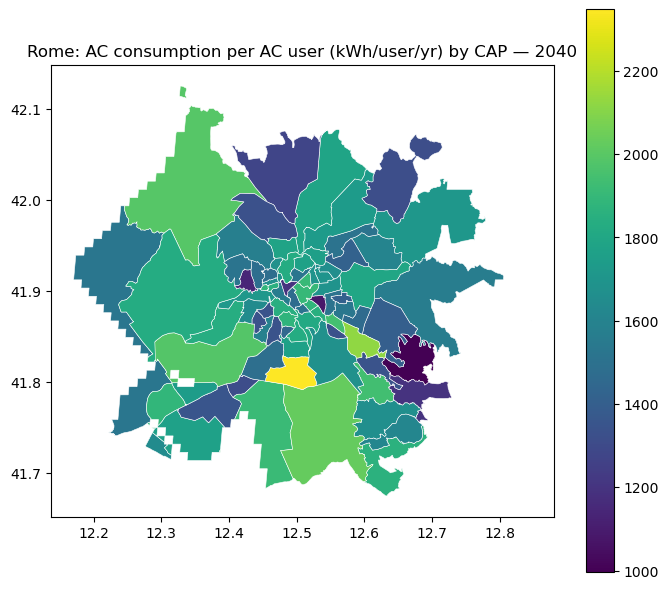

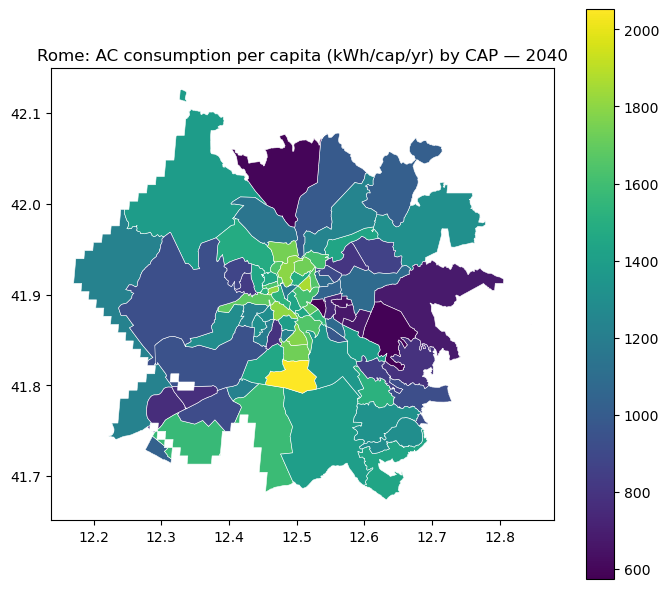


==== CAP-level results for year 2050 ====
City pop: 2,439,832
City AC users: 1,805,513 (AC share ≈ 0.740)
City total AC electricity: 3140.330 GWh/yr
City per-AC-user mean (users-weighted): 1739.300822 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.874065,2456.853271,42632.524910,9.155124e+07,2147.450680,2050
1,78,0.980000,1993.141602,21072.557140,4.116058e+07,1953.278802,2050
2,107,0.980000,1942.581543,8902.081362,1.694716e+07,1903.729984,2050
3,71,0.980000,1927.542236,31531.432824,5.956261e+07,1888.991454,2050
4,110,0.980000,1913.806885,27494.798980,5.156734e+07,1875.530761,2050
5,66,0.972683,1913.391357,14949.075346,2.782208e+07,1861.124026,2050
6,105,0.980000,1863.472412,23855.384233,4.356477e+07,1826.203000,2050
7,61,0.980000,1851.148193,34687.405737,6.292730e+07,1814.125244,2050
8,112,0.980000,1851.117554,22665.329943,4.111707e+07,1814.095211,2050
9,97,0.906411,1967.772461,16040.228279,2.860951e+07,1783.609865,2050


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.528313,1136.618408,26709.217735,1.603863e+07,600.490357,2050
1,53,0.416886,1464.226074,99388.024978,6.066796e+07,610.415161,2050
2,103,0.464348,1334.770996,11103.039511,6.881650e+06,619.798769,2050
3,87,0.451538,1478.731445,20117.226013,1.343234e+07,667.703369,2050
4,88,0.435487,1603.242798,34056.619489,2.377803e+07,698.191039,2050
5,86,0.458501,1531.653809,33503.101674,2.352807e+07,702.265565,2050
6,52,0.430181,1637.435547,8230.952843,5.797826e+06,704.393006,2050
7,93,0.487725,1583.882935,26173.625195,2.021911e+07,772.499451,2050
8,41,0.402864,1975.620239,16883.756630,1.343790e+07,795.906920,2050
9,48,0.444352,1817.526978,35799.713951,2.891266e+07,807.622618,2050



Top 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.892336,1843.630371,76979.061840,1.266411e+08,1645.137332,2050
1,83,0.507749,1910.283813,119545.897838,1.159530e+08,969.945557,2050
2,55,0.939019,1645.207153,73852.011580,1.140926e+08,1544.880860,2050
3,63,0.980000,1553.086548,69003.164905,1.050245e+08,1522.024902,2050
4,62,0.874065,2456.853271,42632.524910,9.155124e+07,2147.450680,2050
5,59,0.715594,1814.657959,63558.918209,8.253493e+07,1298.557739,2050
6,50,0.826456,1999.060425,47773.226599,7.892781e+07,1652.134766,2050
7,89,0.651713,2221.051514,53966.993793,7.811660e+07,1447.488405,2050
8,82,0.980000,1797.832520,43914.131124,7.737125e+07,1761.875854,2050
9,73,0.603981,1881.014526,67438.376385,7.661652e+07,1136.096680,2050


Bottom 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.803997,1973.604980,211.004902,3.348167e+05,1586.772225,2050
1,21,0.770144,1251.365845,1109.067455,1.068843e+06,963.731266,2050
2,24,0.801277,1597.468262,2246.392726,2.875417e+06,1280.015258,2050
3,44,0.624101,1718.172974,3806.946762,4.082243e+06,1072.314088,2050
4,19,0.789369,1042.934082,5379.348809,4.428601e+06,823.259643,2050
5,52,0.430181,1637.435547,8230.952843,5.797826e+06,704.393006,2050
6,103,0.464348,1334.770996,11103.039511,6.881650e+06,619.798769,2050
7,3,0.771750,1376.852051,8858.282648,9.412684e+06,1062.585695,2050
8,33,0.802802,1691.688721,7336.738782,9.963958e+06,1358.090942,2050
9,87,0.451538,1478.731445,20117.226013,1.343234e+07,667.703369,2050


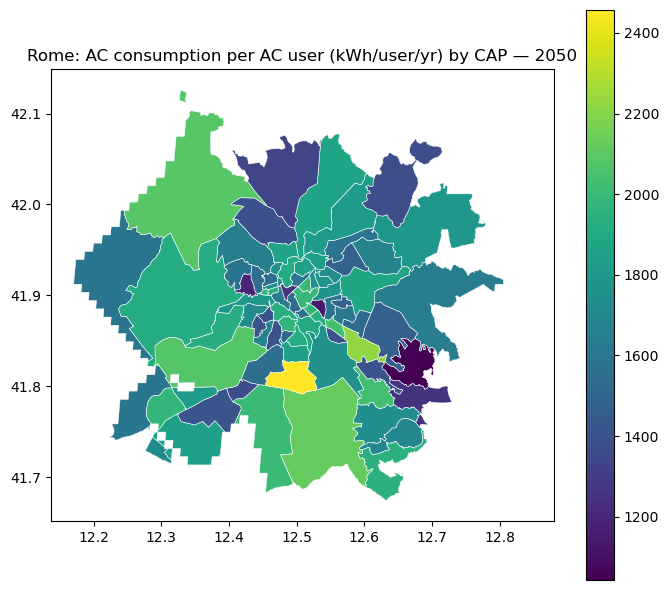

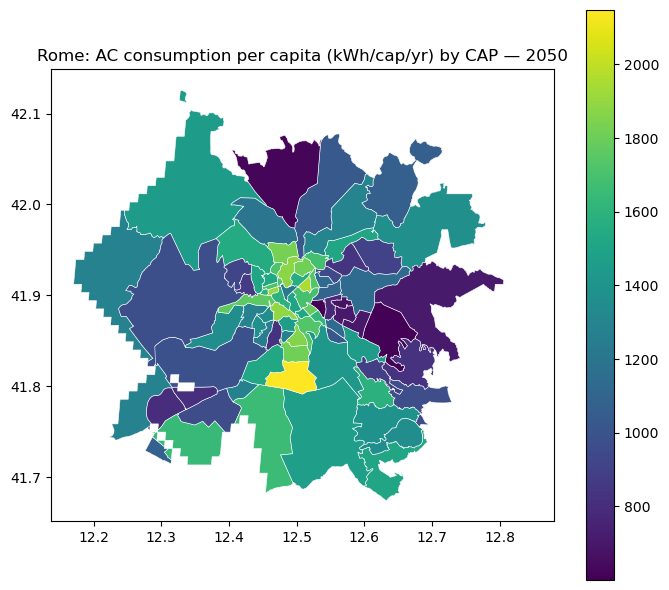

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_map.geojson


In [20]:
per_user_map_by_year = {}
kwh_tot_map_by_year = {}
cap_per_user_by_year = {}
cap_energy_by_year = {}
city_summary_rows = []

for year in years_interest:
    print(f"\n=== Year {year} ===")

    # year-specific population (changes over time) 
    pop_grid = pop_for_year(year)  

    # inputs for this year
    coverage_map = _cov_for_year(year)  # AC penetration map
    H_year = _get_H_for_year(year)      # hazard index
    per_user_city = float(per_user_city_by_year[year])  # kWh per AC user (city)

    # citywide AC share from the map (pop-weighted)
    m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
    ac_city_map = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))

    # target AC share from NB5, if available
    if "ac_city_by_year" in globals() and year in ac_city_by_year:
        ac_city_target = float(ac_city_by_year[year])
    else:
        ac_city_target = ac_city_map

    print(f"AC share from map (city pop-weighted): {ac_city_map:.3f}")
    print(f"AC share from NB5 (target): {ac_city_target:.3f}")

    # CAP-level hazard index (pop-weighted) for dispersion
    CAP_PIX = CITY_MASK & np.isfinite(H_year) & (cap_ids > 0)
    valid = CAP_PIX & np.isfinite(pop_grid)

    dfH = pd.DataFrame({
        "cap_id": cap_ids[valid].ravel().astype(int),
        "pop": pop_grid[valid].ravel().astype(float),
        "H": H_year[valid].ravel().astype(float),
    })

    cap_H = (dfH.groupby("cap_id").apply(_wavg_pop)
             .reset_index(name="H_cap")
             .sort_values("cap_id")
             .reset_index(drop=True))

    H_city = (float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean()))

    # fixed eps per CAP (same CAP is always "high" or "low" across years)
    eps = cap_H["cap_id"].map(eps_by_cap).to_numpy(float)

    cap_draws = cap_H.copy()
    ratio = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0) # spread around the city mean, proportional to local heat

    sigma_cap = sigma0 * (ratio ** gamma) * per_user_city
    draws = per_user_city + sigma_cap * eps
    draws = np.clip(draws, 0.0, np.inf)
    cap_draws["per_user_CAP_raw"] = draws.astype("float32")

    # paint to grid (cap_id -> kWh/user)
    lut = np.full(int(cap_ref["cap_id"].max()) + 1, np.nan, dtype="float32")
    lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()

    per_user_map = np.full(ref_data.shape, np.nan, dtype="float32")
    per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

    # scale so that users-weighted city mean equals per_user_city exactly
    w_users = (coverage_map * pop_grid) * CITY_MASK
    num = np.nansum(per_user_map * w_users)
    den = np.nansum(w_users)
    k = float(per_user_city) / (num / den) if den > 0 else 1.0
    per_user_map *= k

    # totals
    kwh_pc_map = per_user_map * coverage_map
    kwh_tot_map = kwh_pc_map * pop_grid

    # CAP table after scaling
    cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
    cap_per_user = (cap_draws[["cap_id","per_user_CAP"]]
                    .rename(columns={"per_user_CAP": "kwh_per_user_cap"}))

    # diagnostics
    per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users)) if den > 0 else np.nan
    ac_share_from_map = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
    city_total_gwh = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)
    print("Per-user mean (city):", per_user_mean_city)
    print("AC share from map: ", ac_share_from_map)
    print("City total GWh: ", city_total_gwh)

    # CAP aggregation for reporting
    dfE = pd.DataFrame({
        "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
        "pop": pop_grid[CITY_MASK].ravel().astype(float),
        "kwh": kwh_tot_map[CITY_MASK].ravel().astype(float),
    })
    dfE = dfE[dfE["cap_id"] > 0]

    cap_energy = (dfE.groupby("cap_id")
                  .agg(pop_cap=("pop","sum"), kwh_cap=("kwh","sum"))
                  .reset_index())
    cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

    cap_per_user["year"] = year
    cap_energy["year"] = year

    per_user_map_by_year[year] = per_user_map
    kwh_tot_map_by_year[year] = kwh_tot_map
    cap_per_user_by_year[year] = cap_per_user
    cap_energy_by_year[year] = cap_energy

    city_summary_rows.append({
        "year": year,
        "ac_share_city": ac_city_target,
        "ac_share_from_map": ac_share_from_map,
        "per_user_city_input": per_user_city,
        "per_user_city_realized": per_user_mean_city,
        "city_total_GWh": city_total_gwh,
    })

city_summary = pd.DataFrame(city_summary_rows)
display(city_summary)

# CAP-level consumption tables and maps over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
cap_ids = cap_on_ref  # pop_grid will be year-specific inside the loop

def show_rank(df, col, k=15, title=""):
    cols = ["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall","year"]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} CAPs by {col} — {title}"); display(top)
    print(f"Bottom {k} CAPs by {col} — {title}"); display(bot)

all_cap_tbl = []
all_cap_map = []

for year_map in years_maps:
    print(f"\n==== CAP-level results for year {year_map} ====")

    # year-specific population
    pop_grid = pop_for_year(year_map) # change over time 

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]
    cap_per_user = cap_per_user_by_year[year_map]

    # matched pixel universe: within city, with CAP, and finite for all needed layers
    CAP_PIX = (CITY_MASK & (cap_ids > 0) &
               np.isfinite(pop_grid) &
               np.isfinite(coverage_map) &
               np.isfinite(kwh_tot_map))

    # users and pop by CAP
    df_cap_base = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "pop": pop_grid[CAP_PIX].ravel().astype(float),
        "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
    })
    cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                     .agg(pop_cap=("pop","sum"), users_cap=("users","sum")))
    cap_pop_users["ac_share_cap"] = np.where(cap_pop_users["pop_cap"] > 0, cap_pop_users["users_cap"] / cap_pop_users["pop_cap"], np.nan)

    # energy totals by CAP (sum of pixel kWh)
    df_kwh = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "kwh": kwh_tot_map[CAP_PIX].ravel().astype(float),
    })
    cap_energy = (df_kwh.groupby("cap_id", as_index=False)
                  .agg(kwh_cap=("kwh","sum")))

    # merge and compute per-capita
    cap_tbl = (cap_pop_users
               .merge(cap_energy, on="cap_id", how="left")
               .merge(cap_per_user, on="cap_id", how="left"))
    cap_tbl["kwh_pc_overall"] = np.where(cap_tbl["pop_cap"] > 0, cap_tbl["kwh_cap"] / cap_tbl["pop_cap"], np.nan)
    cap_tbl["year"] = year_map
    all_cap_tbl.append(cap_tbl)

    # city checks on the same matched universe
    city_pop = float(np.nansum(pop_grid[CAP_PIX]))
    city_users = float(np.nansum((coverage_map * pop_grid)[CAP_PIX]))
    city_kwh_GWh = float(np.nansum(kwh_tot_map[CAP_PIX])) / 1e6
    per_user_mean_city = float(
        np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"]) / max(city_users, 1e-12)
    )
    print(f"City pop: {city_pop:,.0f}")
    print(f"City AC users: {city_users:,.0f} (AC share ≈ {city_users/city_pop:.3f})")
    print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
    print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.6f} kWh/user/yr")

    # ranks for this year
    show_rank(cap_tbl, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank(cap_tbl, "kwh_cap", k=10, title=f"Total kWh, {year_map}")

    # join to CAP polygons (cap_4326 loaded earlier)
    cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")
    cap_map["year"] = year_map
    cap_map_4326 = cap_map.to_crs("EPSG:4326")
    all_cap_map.append(cap_map_4326)

    # maps for this year
    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_per_user_cap", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

# save all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

cap_tbl_all = pd.concat(all_cap_tbl, ignore_index=True)
cap_tbl_all["kwh_GWh"] = cap_tbl_all["kwh_cap"] / 1e6
cap_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
cap_tbl_all.to_csv(cap_tbl_csv, index=False)

cap_map_all = gpd.GeoDataFrame(pd.concat(all_cap_map, ignore_index=True), crs="EPSG:4326")
cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(cap_map_all[["cap_id","geometry","year", "kwh_per_user_cap","ac_share_cap","kwh_pc_overall","kwh_cap"]]
 .to_file(cap_geojson, driver="GeoJSON"))

print("Saved:", cap_tbl_csv)
print("Saved:", cap_geojson)

And as we said, we downscaled the **electricity consumption to the the CAPs level** 

**Aggregation at the Municipio level**


==== Municipio-level results for year 2030 ====
City diagnostics by universe:
[ALL FUA] per-user=1574.513483 AC-share=0.706 total=2831.493 GWh pop=2,548,154 users=1,798,329
[Municipi-only (muni_on_ref>0)] per-user=1572.013056 AC-share=0.704 total=2663.081 GWh pop=2,406,440 users=1,694,058
[Outside Municipi (muni_id==0)] per-user=1615.140417 AC-share=0.736 total=168.412 GWh pop=141,714 users=104,271

Check: in + out should equal all
users: 1798328.59375 vs 1798328.75
GWh:  2831.49296 vs 2831.492864

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 1574.5135006770122
City total GWh: 2831.492921098766

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.946369,1656.330502,161260.129120,2.527754e+08,1567.500632,2030
1,1,0.939266,1524.444593,179186.877870,2.565703e+08,1431.858774,2030
2,9,0.839698,1700.184811,218657.720248,3.121648e+08,1427.641559,2030
3,8,0.811236,1643.001366,113650.658632,1.514806e+08,1332.861322,2030
4,15,0.823670,1466.976601,99254.233698,1.199294e+08,1208.305113,2030
5,3,0.727116,1605.003291,148399.737365,1.731859e+08,1167.022821,2030
6,12,0.750361,1480.620465,131663.470462,1.462780e+08,1110.999196,2030
7,7,0.680523,1631.049241,248261.719551,2.755621e+08,1109.966322,2030
8,14,0.708975,1492.173420,158462.193416,1.676393e+08,1057.913603,2030
9,13,0.641662,1584.972251,130701.853779,1.329260e+08,1017.016669,2030


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.407403,1366.962079,129944.772862,7.236683e+07,556.904486,2030
1,5,0.491109,1482.401110,175712.889069,1.279226e+08,728.020390,2030
2,4,0.565051,1528.302522,170679.730472,1.473936e+08,863.568466,2030
3,11,0.535108,1655.212906,119803.339032,1.061119e+08,885.717347,2030
4,10,0.651910,1533.769052,220800.463360,2.207740e+08,999.880041,2030
5,13,0.641662,1584.972251,130701.853779,1.329260e+08,1017.016669,2030
6,14,0.708975,1492.173420,158462.193416,1.676393e+08,1057.913603,2030
7,7,0.680523,1631.049241,248261.719551,2.755621e+08,1109.966322,2030
8,12,0.750361,1480.620465,131663.470462,1.462780e+08,1110.999196,2030
9,3,0.727116,1605.003291,148399.737365,1.731859e+08,1167.022821,2030



Top 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.839698,1700.184811,218657.720248,3.121648e+08,1427.641559,2030
1,7,0.680523,1631.049241,248261.719551,2.755621e+08,1109.966322,2030
2,1,0.939266,1524.444593,179186.877870,2.565703e+08,1431.858774,2030
3,2,0.946369,1656.330502,161260.129120,2.527754e+08,1567.500632,2030
4,10,0.651910,1533.769052,220800.463360,2.207740e+08,999.880041,2030
5,3,0.727116,1605.003291,148399.737365,1.731859e+08,1167.022821,2030
6,14,0.708975,1492.173420,158462.193416,1.676393e+08,1057.913603,2030
7,8,0.811236,1643.001366,113650.658632,1.514806e+08,1332.861322,2030
8,4,0.565051,1528.302522,170679.730472,1.473936e+08,863.568466,2030
9,12,0.750361,1480.620465,131663.470462,1.462780e+08,1110.999196,2030


Bottom 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.407403,1366.962079,129944.772862,7.236683e+07,556.904486,2030
1,11,0.535108,1655.212906,119803.339032,1.061119e+08,885.717347,2030
2,15,0.823670,1466.976601,99254.233698,1.199294e+08,1208.305113,2030
3,5,0.491109,1482.401110,175712.889069,1.279226e+08,728.020390,2030
4,13,0.641662,1584.972251,130701.853779,1.329260e+08,1017.016669,2030
5,12,0.750361,1480.620465,131663.470462,1.462780e+08,1110.999196,2030
6,4,0.565051,1528.302522,170679.730472,1.473936e+08,863.568466,2030
7,8,0.811236,1643.001366,113650.658632,1.514806e+08,1332.861322,2030
8,14,0.708975,1492.173420,158462.193416,1.676393e+08,1057.913603,2030
9,3,0.727116,1605.003291,148399.737365,1.731859e+08,1167.022821,2030


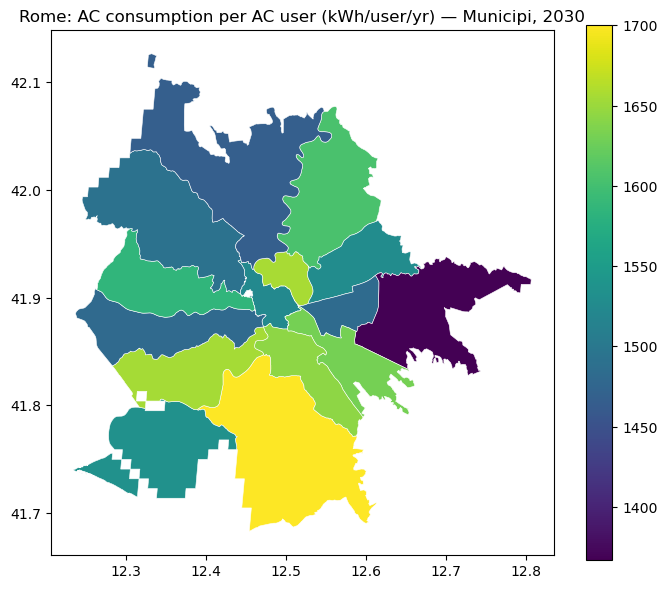

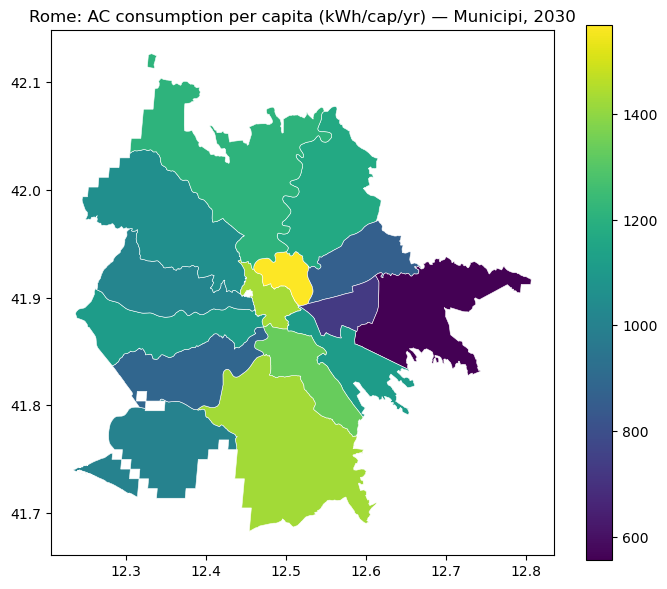


==== Municipio-level results for year 2040 ====
City diagnostics by universe:
[ALL FUA] per-user=1662.143769 AC-share=0.740 total=3060.844 GWh pop=2,488,442 users=1,841,504
[Municipi-only (muni_on_ref>0)] per-user=1659.518258 AC-share=0.738 total=2878.092 GWh pop=2,351,216 users=1,734,293
[Outside Municipi (muni_id==0)] per-user=1704.617084 AC-share=0.781 total=182.752 GWh pop=137,226 users=107,210

Check: in + out should equal all
users: 1841503.5078125 vs 1841503.625
GWh:  3060.843744 vs 3060.843776

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 1662.1439003308556
City total GWh: 3060.843980122537

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.957551,1748.545756,157559.982686,2.638060e+08,1674.320881,2040
1,9,0.873218,1800.559192,213640.299554,3.359026e+08,1572.281243,2040
2,1,0.955252,1612.202172,175075.398325,2.696264e+08,1540.058854,2040
3,8,0.857853,1733.547043,111042.568582,1.651347e+08,1487.129276,2040
4,15,0.859557,1543.858883,96976.824863,1.286917e+08,1327.035251,2040
5,3,0.771856,1693.615844,144992.634123,1.895384e+08,1307.227627,2040
6,7,0.722218,1721.165632,242563.965960,3.015206e+08,1243.056181,2040
7,12,0.791253,1562.892261,128642.424919,1.590849e+08,1236.643813,2040
8,14,0.746774,1575.279639,154826.245600,1.821342e+08,1176.378068,2040
9,13,0.680455,1672.433836,127702.865341,1.453278e+08,1138.015557,2040


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.431104,1442.537934,126963.169546,7.895642e+07,621.884469,2040
1,5,0.520361,1564.357598,171681.120590,1.397538e+08,814.031157,2040
2,4,0.599133,1612.675747,166760.643746,1.611252e+08,966.206463,2040
3,11,0.567050,1746.501087,117053.902880,1.159247e+08,990.353194,2040
4,10,0.691826,1618.515264,215734.151018,2.415644e+08,1119.731740,2040
5,13,0.680455,1672.433836,127702.865341,1.453278e+08,1138.015557,2040
6,14,0.746774,1575.279639,154826.245600,1.821342e+08,1176.378068,2040
7,12,0.791253,1562.892261,128642.424919,1.590849e+08,1236.643813,2040
8,7,0.722218,1721.165632,242563.965960,3.015206e+08,1243.056181,2040
9,3,0.771856,1693.615844,144992.634123,1.895384e+08,1307.227627,2040



Top 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.873218,1800.559192,213640.299554,3.359026e+08,1572.281243,2040
1,7,0.722218,1721.165632,242563.965960,3.015206e+08,1243.056181,2040
2,1,0.955252,1612.202172,175075.398325,2.696264e+08,1540.058854,2040
3,2,0.957551,1748.545756,157559.982686,2.638060e+08,1674.320881,2040
4,10,0.691826,1618.515264,215734.151018,2.415644e+08,1119.731740,2040
5,3,0.771856,1693.615844,144992.634123,1.895384e+08,1307.227627,2040
6,14,0.746774,1575.279639,154826.245600,1.821342e+08,1176.378068,2040
7,8,0.857853,1733.547043,111042.568582,1.651347e+08,1487.129276,2040
8,4,0.599133,1612.675747,166760.643746,1.611252e+08,966.206463,2040
9,12,0.791253,1562.892261,128642.424919,1.590849e+08,1236.643813,2040


Bottom 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.431104,1442.537934,126963.169546,7.895642e+07,621.884469,2040
1,11,0.567050,1746.501087,117053.902880,1.159247e+08,990.353194,2040
2,15,0.859557,1543.858883,96976.824863,1.286917e+08,1327.035251,2040
3,5,0.520361,1564.357598,171681.120590,1.397538e+08,814.031157,2040
4,13,0.680455,1672.433836,127702.865341,1.453278e+08,1138.015557,2040
5,12,0.791253,1562.892261,128642.424919,1.590849e+08,1236.643813,2040
6,4,0.599133,1612.675747,166760.643746,1.611252e+08,966.206463,2040
7,8,0.857853,1733.547043,111042.568582,1.651347e+08,1487.129276,2040
8,14,0.746774,1575.279639,154826.245600,1.821342e+08,1176.378068,2040
9,3,0.771856,1693.615844,144992.634123,1.895384e+08,1307.227627,2040


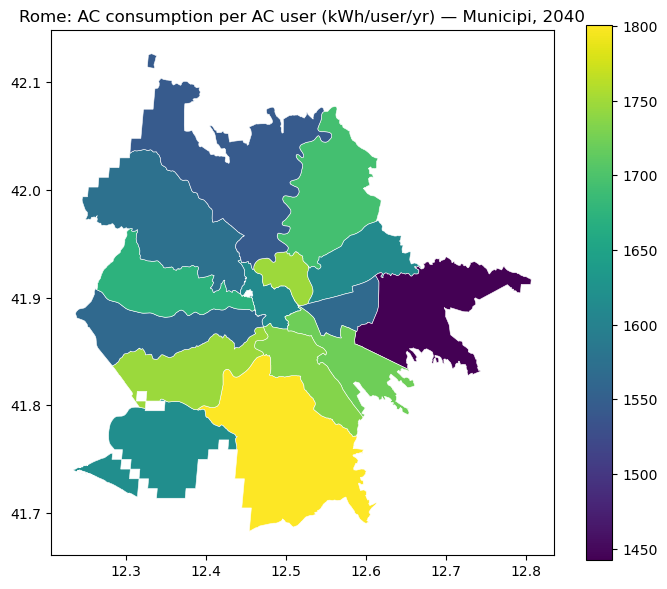

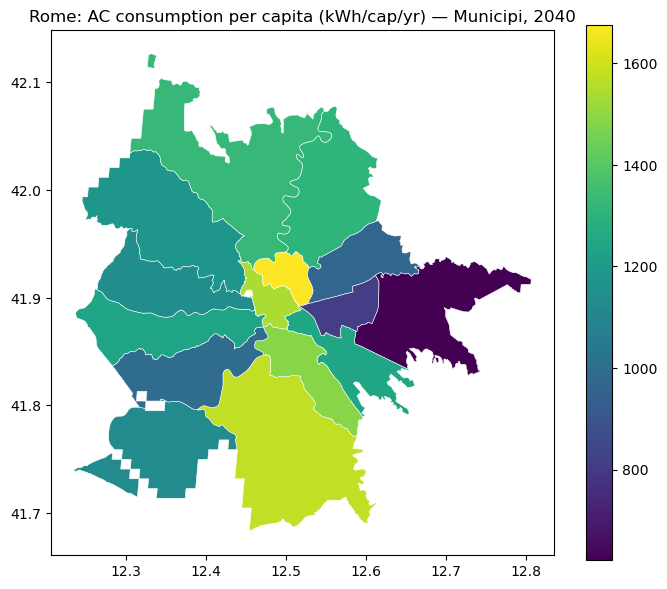


==== Municipio-level results for year 2050 ====
City diagnostics by universe:
[ALL FUA] per-user=1739.300776 AC-share=0.740 total=3140.330 GWh pop=2,439,832 users=1,805,513
[Municipi-only (muni_on_ref>0)] per-user=1736.557128 AC-share=0.738 total=2953.428 GWh pop=2,305,724 users=1,700,738
[Outside Municipi (muni_id==0)] per-user=1783.836856 AC-share=0.781 total=186.901 GWh pop=134,109 users=104,775

Check: in + out should equal all
users: 1805512.703125 vs 1805512.75
GWh:  3140.32968 vs 3140.329728

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 1739.3009782491965
City total GWh: 3140.329813360022

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.957551,1829.717237,154511.615120,2.707116e+08,1752.046677,2050
1,9,0.873218,1884.194953,209506.827821,3.447045e+08,1645.313728,2050
2,1,0.955252,1687.037866,171688.153667,2.766833e+08,1611.545767,2050
3,8,0.857854,1814.056304,108894.064064,1.694604e+08,1556.194724,2050
4,15,0.859557,1615.558752,95100.580697,1.320629e+08,1388.665394,2050
5,3,0.771856,1772.205924,142186.661340,1.944955e+08,1367.888192,2050
6,7,0.722218,1801.077753,237870.553710,3.094149e+08,1300.769943,2050
7,12,0.791253,1635.397213,126153.535742,1.632444e+08,1294.013619,2050
8,14,0.746774,1648.396635,151830.769012,1.869006e+08,1230.979928,2050
9,13,0.680455,1750.062453,125232.151376,1.491312e+08,1190.838327,2050


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.431104,1509.486385,124506.794621,8.102233e+07,650.746278,2050
1,5,0.520361,1636.991176,168359.546703,1.434132e+08,851.826858,2050
2,4,0.599133,1687.552142,163533.186738,1.653431e+08,1011.067759,2050
3,11,0.567050,1827.540456,114789.020758,1.189567e+08,1036.306886,2050
4,10,0.691826,1693.625688,211560.267905,2.478841e+08,1171.695121,2050
5,13,0.680455,1750.062453,125232.151376,1.491312e+08,1190.838327,2050
6,14,0.746774,1648.396635,151830.769012,1.869006e+08,1230.979928,2050
7,12,0.791253,1635.397213,126153.535742,1.632444e+08,1294.013619,2050
8,7,0.722218,1801.077753,237870.553710,3.094149e+08,1300.769943,2050
9,3,0.771856,1772.205924,142186.661340,1.944955e+08,1367.888192,2050



Top 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.873218,1884.194953,209506.827821,3.447045e+08,1645.313728,2050
1,7,0.722218,1801.077753,237870.553710,3.094149e+08,1300.769943,2050
2,1,0.955252,1687.037866,171688.153667,2.766833e+08,1611.545767,2050
3,2,0.957551,1829.717237,154511.615120,2.707116e+08,1752.046677,2050
4,10,0.691826,1693.625688,211560.267905,2.478841e+08,1171.695121,2050
5,3,0.771856,1772.205924,142186.661340,1.944955e+08,1367.888192,2050
6,14,0.746774,1648.396635,151830.769012,1.869006e+08,1230.979928,2050
7,8,0.857854,1814.056304,108894.064064,1.694604e+08,1556.194724,2050
8,4,0.599133,1687.552142,163533.186738,1.653431e+08,1011.067759,2050
9,12,0.791253,1635.397213,126153.535742,1.632444e+08,1294.013619,2050


Bottom 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.431104,1509.486385,124506.794621,8.102233e+07,650.746278,2050
1,11,0.567050,1827.540456,114789.020758,1.189567e+08,1036.306886,2050
2,15,0.859557,1615.558752,95100.580697,1.320629e+08,1388.665394,2050
3,5,0.520361,1636.991176,168359.546703,1.434132e+08,851.826858,2050
4,13,0.680455,1750.062453,125232.151376,1.491312e+08,1190.838327,2050
5,12,0.791253,1635.397213,126153.535742,1.632444e+08,1294.013619,2050
6,4,0.599133,1687.552142,163533.186738,1.653431e+08,1011.067759,2050
7,8,0.857854,1814.056304,108894.064064,1.694604e+08,1556.194724,2050
8,14,0.746774,1648.396635,151830.769012,1.869006e+08,1230.979928,2050
9,3,0.771856,1772.205924,142186.661340,1.944955e+08,1367.888192,2050


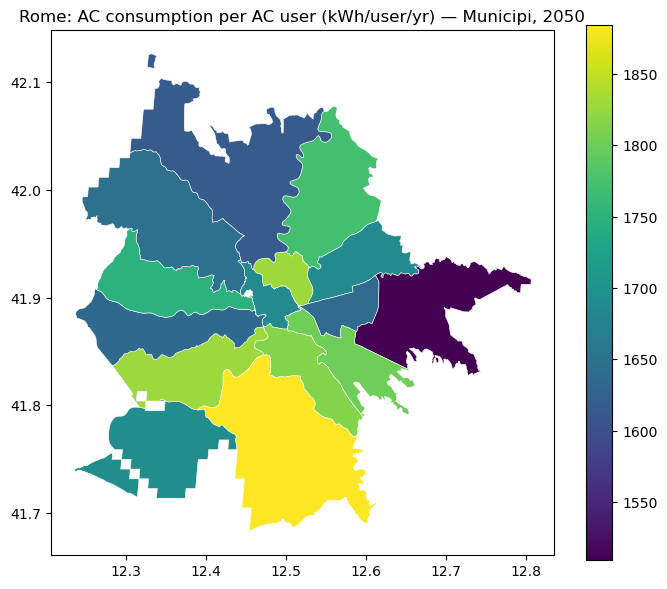

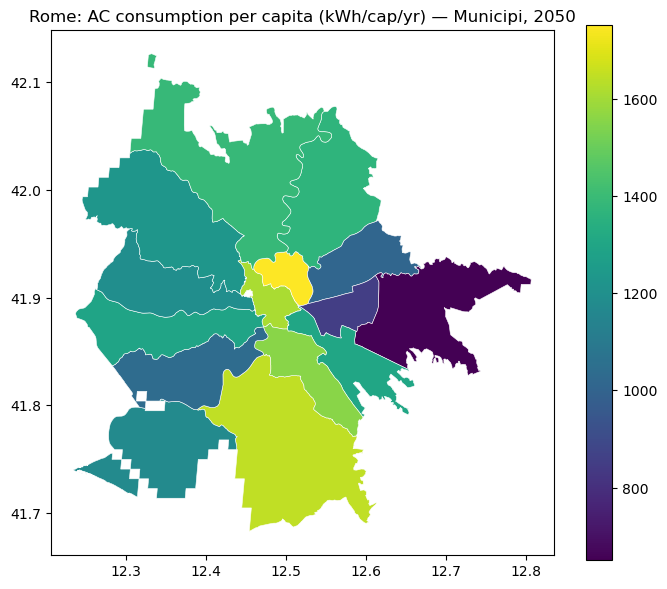

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_map.geojson


In [21]:
# Municipio-level AC electricity: per-user, per-capita, totals over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
assert 'muni_on_ref' in globals(), "muni_on_ref raster missing."
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GeoDataFrame missing."
# pop_grid will be year-specific inside the loop

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

def show_rank_muni(df_in, col, k=10, title=""):
    cols = ["muni_id","ac_share_muni","kwh_per_user_muni", "pop_muni","kwh_muni","kwh_pc_overall","year"]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}"); display(top)
    print(f"Bottom {k} Municipi by {col} — {title}"); display(bot)

all_muni_tbl = []
all_muni_map = []

for year_map in years_maps:
    print(f"\n==== Municipio-level results for year {year_map} ====")

    # year-specific population
    pop_grid = pop_for_year(year_map)  # NEW

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]

    def city_diag(mask, label):
        users = float(np.nansum((coverage_map * pop_grid)[mask]))
        per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
        kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
        pop = float(np.nansum(pop_grid[mask]))
        print(f"[{label}] per-user={per_user:.6f} AC-share={users/pop:.3f} "
              f"total={kwh:.3f} GWh pop={pop:,.0f} users={users:,.0f}")
        return per_user, users, kwh

    # universes (keep id==0 as "outside" bucket)
    mask_all = CITY_MASK
    mask_in = CITY_MASK & (muni_on_ref > 0)
    mask_out = CITY_MASK & (muni_on_ref == 0)

    print("City diagnostics by universe:")
    pu_all, u_all, k_all = city_diag(mask_all, "ALL FUA")
    pu_in, u_in, k_in = city_diag(mask_in, "Municipi-only (muni_on_ref>0)")
    pu_out, u_out, k_out = city_diag(mask_out, "Outside Municipi (muni_id==0)")

    print("\nCheck: in + out should equal all")
    print("users:", u_in + u_out, "vs", u_all)
    print("GWh: ", k_in + k_out, "vs", k_all)

    # Build pixel to Municipio table over the full city mask (includes muni_id==0)
    valid_all = (CITY_MASK & np.isfinite(per_user_map) & np.isfinite(kwh_tot_map) & np.isfinite(pop_grid) & np.isfinite(coverage_map))
    df = pd.DataFrame({
        "muni_id": muni_on_ref[valid_all].ravel().astype(int), # includes 0
        "pop": pop_grid[valid_all].ravel().astype(float),
        "users": (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
        "kwh": kwh_tot_map[valid_all].ravel().astype(float),
        "per_user": per_user_map[valid_all].ravel().astype(float),
    })

    # users-weighted per-user by municipio
    per_user_by_muni = (df.groupby("muni_id")
                        .apply(lambda g: _wavg(g["per_user"], g["users"]))
                        .reset_index(name="kwh_per_user_muni"))

    # totals by municipio
    muni_tbl_all = (df.groupby("muni_id", as_index=False)
                    .agg(pop_muni=("pop","sum"), users_muni=("users","sum"), kwh_muni=("kwh","sum"))
                    .merge(per_user_by_muni, on="muni_id", how="left"))

    # rates
    muni_tbl_all["ac_share_muni"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["users_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["kwh_pc_overall"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["kwh_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["year"] = year_map
    all_muni_tbl.append(muni_tbl_all)

    # city diagnostics from grouped table
    users_sum = float(muni_tbl_all["users_muni"].sum())
    per_user_from_groups = float(
        np.nansum(muni_tbl_all["kwh_per_user_muni"] * muni_tbl_all["users_muni"]) / max(users_sum, 1e-12)
    )
    kwh_sum = float(muni_tbl_all["kwh_muni"].sum()) / 1e6
    print("\nFrom groupby (includes muni_id=0):")
    print("Users-weighted per-user mean (city):", per_user_from_groups)
    print("City total GWh:", kwh_sum)

    # tables and maps for Municipi only (exclude id==0 for reporting)
    muni_only = muni_tbl_all[muni_tbl_all["muni_id"] > 0].copy()
    show_rank_muni(muni_only, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank_muni(muni_only, "kwh_muni", k=10, title=f"Total kWh, {year_map}")

    # map join
    muni_map = (muni[["muni_id","muni_name","geometry"]] if "muni_name" in muni.columns else muni[["muni_id","geometry"]]).merge(muni_only, on="muni_id", how="left")
    muni_map["year"] = year_map
    muni_map_4326 = muni_map.to_crs("EPSG:4326")
    all_muni_map.append(muni_map_4326)

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_per_user_muni", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

# saving all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

muni_tbl_all_years = pd.concat(all_muni_tbl, ignore_index=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
(muni_tbl_all_years
 .assign(kwh_GWh=lambda d: d["kwh_muni"]/1e6)
 .to_csv(muni_csv, index=False))

muni_map_all = gpd.GeoDataFrame(pd.concat(all_muni_map, ignore_index=True), crs="EPSG:4326")
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"
(muni_map_all[["muni_id","geometry","year", "kwh_per_user_muni","ac_share_muni","kwh_pc_overall","kwh_muni"]]
 .to_file(muni_geo, driver="GeoJSON"))

print("Saved:", muni_csv)
print("Saved:", muni_geo)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Why do the “per AC user” and “per capita” maps look different?
The two maps use different denominators. The per-AC-user map shows the average annual AC electricity use only among households that actually own AC in each CAP. We construct this by drawing CAP-level values around the city-wide mean (from the NUTS data) with a spread proportional to local heat (hazard), and then rescaling so that the city-wide users-weighted mean exactly matches the NUTS value. The per-capita map divides the same total AC electricity by the entire population in each CAP, not just AC users. It is approximately kWh per capita ≈ AC ownership share × kWh per AC user. As a result, a CAP with low ownership but high usage among users will still look low on the per-capita map, while a CAP with high ownership looks high per capita even if individual users are not especially intensive. Municipi vs CAP: Municipio values are simply population-weighted aggregates of the CAPs (or more precisely, pixel-level data) that fall inside each Municipio. Rankings of total kWh differ from per-capita rankings because total consumption is total kWh=kWh per capita×population, so large Municipi with moderate per-capita use can still have very high totals.
</blockquote>